# RNA reactivity prediction using RNN
---
**Date:** 21 Feb 2026  
**Description:** Implementing a RNN for RNA reactivity prediction. Data from Kaggle competititon: https://www.kaggle.com/competitions/stanford-covid-vaccine/data.

---

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import json
import pandas as pd
import numpy as np
import os

In [2]:
# Load train and test data from JSON file

train_data = pd.read_json('train.json', lines=True)
test_data = pd.read_json('test.json', lines=True)

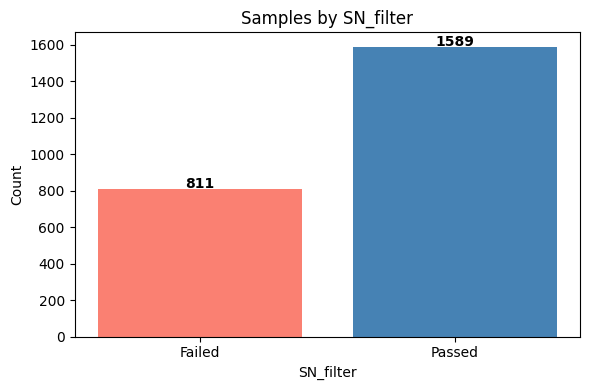

In [4]:
# Histogram of SN_filter values (passed vs failed)

# Count passed and failed
counts = train_data['SN_filter'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(['Failed', 'Passed'], counts.values, color=['salmon', 'steelblue'])
plt.title('Samples by SN_filter')
plt.xlabel('SN_filter')
plt.ylabel('Count')

# Add count labels on top of bars
for i, count in enumerate(counts.values):
    plt.text(i, count + 5, str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [5]:
# One-hot encode sequences function

vocab = {'A': 0, 'C': 1, 'G': 2, 'U': 3}

def one_hot_encode(sequence):
    # Step 1: convert characters to integer indices
    indices = torch.tensor([vocab[c] for c in sequence])
    
    # Step 2: one-hot encode
    encoding = F.one_hot(indices, num_classes=4)
    
    return encoding.float()  # convert from int64 to float32 for the model

In [6]:
# Create dataset

class RNADataset(Dataset):
    def __init__(self, df):
        df = df[df['SN_filter'] == 1.0].reset_index(drop=True)
    
        # Pre-encode everything upfront
        self.sequences = torch.stack([
            one_hot_encode(seq) for seq in df['sequence'].values
        ])

        # Trim sequences to first 68 nucleotides
        self.sequences = self.sequences[:, :68, :]
    
        self.labels = torch.tensor(
            np.array(df['reactivity'].tolist(), dtype=np.float32)
        )

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        sequence = self.sequences[idx]
        reactivity = self.labels[idx]
        return sequence, reactivity

# Create dataset and dataloader
dataset = RNADataset(train_data)

# Split dataset into train and validation sets
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [0.8, 0.2])

# Create dataloader
dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [8]:
class RNAModel(nn.Module):
    def __init__(self, input_size=4, hidden_size=32, num_layers=2):
        super(RNAModel, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(in_features = hidden_size, out_features = 1)  # Output is a single reactivity value

    def forward(self, x):
        out, _ = self.rnn(x)  # out: (batch_size, seq_length, hidden_size); discard final hidden state
        out = self.fc(out)    # (batch_size, seq_length, 1)
        return out.squeeze(-1)  # Return as (batch_size, seq_length)

In [9]:
model = RNAModel(input_size=4, hidden_size=256, num_layers=10)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Epoch [1/100], Loss: 0.2145
Epoch [2/100], Loss: 0.1606
Epoch [3/100], Loss: 0.1553
Epoch [4/100], Loss: 0.1553
Epoch [5/100], Loss: 0.1534
Epoch [6/100], Loss: 0.1547
Epoch [7/100], Loss: 0.1539
Epoch [8/100], Loss: 0.1559
Epoch [9/100], Loss: 0.1535
Epoch [10/100], Loss: 0.1555
Epoch [11/100], Loss: 0.1533
Epoch [12/100], Loss: 0.1539
Epoch [13/100], Loss: 0.1533
Epoch [14/100], Loss: 0.1525
Epoch [15/100], Loss: 0.1530
Epoch [16/100], Loss: 0.1517
Epoch [17/100], Loss: 0.1533
Epoch [18/100], Loss: 0.1523
Epoch [19/100], Loss: 0.1516
Epoch [20/100], Loss: 0.1514
Epoch [21/100], Loss: 0.1478
Epoch [22/100], Loss: 0.1474
Epoch [23/100], Loss: 0.1450
Epoch [24/100], Loss: 0.1416
Epoch [25/100], Loss: 0.1417
Epoch [26/100], Loss: 0.1361
Epoch [27/100], Loss: 0.1348
Epoch [28/100], Loss: 0.1307
Epoch [29/100], Loss: 0.1252
Epoch [30/100], Loss: 0.1215
Epoch [31/100], Loss: 0.1164
Epoch [32/100], Loss: 0.1143
Epoch [33/100], Loss: 0.1085
Epoch [34/100], Loss: 0.1025
Epoch [35/100], Loss: 0

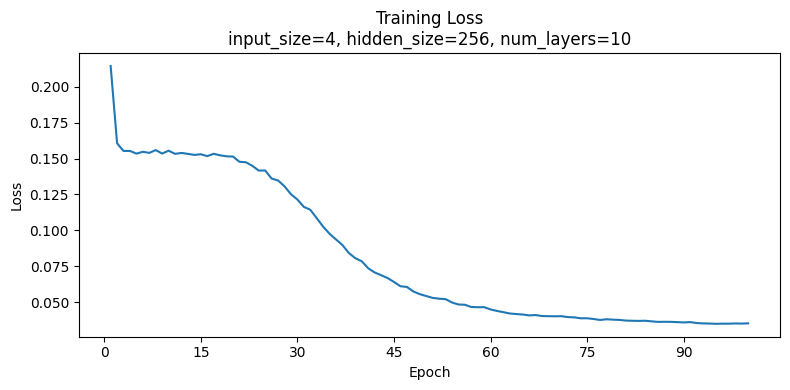

In [10]:
train_losses = []
num_epochs = 100

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for sequences, reactivity in dataloader:
        # sequences:  (batch_size, 107, 4)
        # reactivity: (batch_size,)

        outputs = model(sequences)           # forward pass
        loss = criterion(outputs, reactivity) # compare predictions to labels

        optimizer.zero_grad()  # clear old gradients
        loss.backward()        # backpropagation
        optimizer.step()       # update weights

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    train_losses.append(avg_loss)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')

# Plot training loss curve
os.makedirs('./Figures', exist_ok=True)

# Extract info directly from the model
hidden_size = model.rnn.hidden_size
num_layers = model.rnn.num_layers
input_size = model.rnn.input_size

plt.figure(figsize=(8, 4))
plt.plot(range(1, num_epochs+1), train_losses)
plt.title(f'Training Loss\ninput_size={input_size}, hidden_size={hidden_size}, num_layers={num_layers}')
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.tight_layout()
plt.savefig(f'./Figures/training_loss_hidden{hidden_size}_layers{num_layers}.png', dpi=150)
plt.show()